# TFM · GNN × GDELT × SP500

Orquestador de entrenamiento. Este notebook ejecuta el pipeline de extremo a extremo:

1. Clonar el repo y instalar dependencias.
2. Descargar datos de GDELT y financieros.
3. Preprocesar y construir el dataset.
4. Entrenar la HGNN con walk-forward.
5. Evaluar y comparar con baselines.

Editar los parámetros de `config.py` (en el repo) para ajustar el experimento. No conviene poner lógica nueva en este notebook: si algo se reusa, va a `src/`.

## 1. Setup

En la primera ejecución en Colab hay que clonar el repo e instalar PyG. PyTorch Geometric requiere instalación específica según la versión de torch+CUDA de Colab.

In [10]:
# Detectar si estamos en Colab
try:
    import google.colab  # type: ignore
    EN_COLAB = True
except ImportError:
    EN_COLAB = False
print('En Colab:', EN_COLAB)

En Colab: True


In [11]:
if EN_COLAB:
    # AJUSTAR: reemplazar <usuario> por vuestro usuario de GitHub
    # Si el repo es privado, guardar el token en los secrets de Colab y descomentar las dos líneas siguientes:
    # from google.colab import userdata
    # token = userdata.get('GITHUB_TOKEN')
    # !git clone https://{token}@github.com/<usuario>/ai-gnn-gdelt-sp500.git
    !git clone https://github.com/ricardmartin/ai-gnn-gdelt-sp500.git
    %cd ai-gnn-gdelt-sp500
    !pip install -q -r requirements.txt

Cloning into 'ai-gnn-gdelt-sp500'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 144 (delta 40), reused 101 (delta 27), pack-reused 25 (from 1)
Receiving objects: 100% (144/144), 98.79 MiB | 19.69 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/ai-gnn-gdelt-sp500/ai-gnn-gdelt-sp500


In [12]:
import sys
from pathlib import Path
# Asegurar que el cwd está en el repo (importar src.* requiere esto)
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

## 2. Descarga de datos

Definir el rango de fechas y descargar GDELT + SP500. Ajustar en `config.py` o sobreescribir aquí.

In [13]:
from datetime import date
import config
from src.datos.descarga_gdelt import descargar_rango
from src.datos.descarga_financiero import descargar_sp500, descargar_vix, descargar_macro_fred

config.FECHA_INICIO = "2018-01-01"
config.FECHA_FIN = "2021-12-31"

FECHA_INI = date.fromisoformat(config.FECHA_INICIO)
FECHA_FIN = date.fromisoformat(config.FECHA_FIN)

rutas_gdelt = descargar_rango(FECHA_INI, FECHA_FIN)
print(f'GDELT: {len(rutas_gdelt)} días descargados')

GDELT: 1461 días descargados


In [14]:
precios = descargar_sp500(FECHA_INI, FECHA_FIN)
vix = descargar_vix(FECHA_INI, FECHA_FIN)
try:
    macro = descargar_macro_fred(FECHA_INI, FECHA_FIN)
except Exception as e:
    print('Macro FRED no disponible:', e)
    macro = None

print('SP500:', len(precios), 'sesiones')
print('VIX:', len(vix), 'puntos')

SP500: 1007 sesiones
VIX: 1007 puntos


## 3. Preprocesado y construcción del dataset

In [15]:
from pathlib import Path
from src.datos.preprocesar import (
    preprocesar_y_agregar_por_tramos,
    cargar_agregados_de_disco,
)

# Carpeta donde se guardan los agregados ya procesados. Apuntala a tu Drive
# para que sobrevivan a desconexiones de Colab, por ejemplo:
# DIR_AGREGADOS = Path("/content/drive/MyDrive/TFM/agregados")
DIR_AGREGADOS = Path("data/agregados")

# Procesa GDELT POR TRAMOS: el pico de RAM es el de un tramo, no el del rango
# completo. Es resumible: si Colab se corta, vuelve a ejecutar y sigue donde iba.
# Baja dias_por_tramo si aun vas justo de RAM (p.ej. 90); subelo si te sobra.
preprocesar_y_agregar_por_tramos(rutas_gdelt, DIR_AGREGADOS, dias_por_tramo=180)

# Carga el "concentrado" (pequeno) desde disco. Ya NO se mantiene df_eventos
# entero en memoria.
df_agregado, df_participacion = cargar_agregados_de_disco(DIR_AGREGADOS)
print("Aristas agregadas:", len(df_agregado))
print("Filas de participacion (nodo):", len(df_participacion))


Aristas agregadas: 849762
Filas de participacion (nodo): 369581


In [16]:
from src.datos.etiquetas import construir_etiquetas_diarias

etiquetas = construir_etiquetas_diarias(precios)
print(etiquetas.head())
print('Distribución de clases:')
print(etiquetas['clase'].value_counts().sort_index())

  fecha_target   retorno  clase fecha_grafo
0   2018-01-03  0.006399      1  2018-01-02
1   2018-01-04  0.004029      1  2018-01-03
2   2018-01-05  0.007034      2  2018-01-04
3   2018-01-08  0.001662      1  2018-01-05
4   2018-01-09  0.001303      1  2018-01-08
Distribución de clases:
clase
0    176
1    573
2    257
Name: count, dtype: int64


In [19]:
from src.datos.preprocesar import (
    preprocesar_y_agregar_por_tramos,
    cargar_agregados_de_disco,
)
from src.datos.etiquetas import construir_etiquetas_diarias
from src.datos.dataset import DatasetGrafoDiario

In [20]:
# Filtrar etiquetas a fechas para las que tenemos datos de GDELT
import pandas as pd
from src.datos.dataset import DatasetGrafoDiario

fechas_gdelt = set(pd.to_datetime(df_agregado['fecha']).dt.normalize().unique())
etiquetas_validas = etiquetas[pd.to_datetime(etiquetas['fecha_grafo']).dt.normalize().isin(fechas_gdelt)].reset_index(drop=True)
print(f'Etiquetas alineadas: {len(etiquetas_validas)}/{len(etiquetas)}')

dataset = DatasetGrafoDiario(
    eventos_agregados=df_agregado,
    etiquetas=etiquetas_validas,
    precios_sp500=precios,
    macro=macro,
    vix=vix,
    participacion=df_participacion,
    precomputar=False,
)
print('Dataset:', len(dataset), 'muestras')

Etiquetas alineadas: 1006/1006
Dataset: 1006 muestras


## 4. Walk-forward + entrenamiento

In [21]:
import torch
from src.entrenamiento.walkforward import construir_folds
from src.entrenamiento.loop import entrenar_walkforward

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', dispositivo)

folds = construir_folds(
    fechas=etiquetas_validas['fecha_grafo'],
    num_folds=3,                # AJUSTAR: depende del rango temporal
    train_inicial_dias=60,      # AJUSTAR
    validacion_dias=20,         # AJUSTAR
)
print(f'{len(folds)} folds construidos')

Dispositivo: cpu
3 folds construidos


In [22]:
retornos_por_indice = etiquetas_validas['retorno'].values

resultado = entrenar_walkforward(
    dataset=dataset,
    folds=folds,
    semillas=(0, 1, 2),
    dispositivo=dispositivo,
    retornos_por_indice=retornos_por_indice,
)
print(resultado.resumen_final())

folds=9 | accuracy = 0.5104 ± 0.1759 | f1_macro = 0.2365 ± 0.0559 | rent_estrategia = +0.68% ± 1.20% | rent_buy_hold = -1.00% ± 3.19% | vs_BH = +1.68pp ± 2.55pp | sharpe = 0.60 ± 0.98 | maxDD = -0.80% ± 1.20%


## 5. Baselines

Comparación con modelos clásicos para aislar la aportación de la GNN.

In [23]:
from src.modelo.baselines import (
    BaselineNaive, construir_matriz_features,
    entrenar_logistica, entrenar_xgboost,
)
from src.entrenamiento.evaluacion import calcular_metricas

# Construir X, y aplanados desde el dataset entero
X, y = construir_matriz_features(dataset)
print('X shape:', X.shape, '| y shape:', y.shape)

# Usar el primer fold como referencia rápida
f0 = folds[0]
X_tr, y_tr = X[f0.idx_train], y[f0.idx_train]
X_va, y_va = X[f0.idx_val], y[f0.idx_val]

naive = BaselineNaive().fit(X_tr, y_tr)
logr = entrenar_logistica(X_tr, y_tr)
xgb = entrenar_xgboost(X_tr, y_tr)

for nombre, modelo in [('naive', naive), ('logística', logr), ('xgboost', xgb)]:
    m = calcular_metricas(y_va, modelo.predict(X_va))
    print(f'{nombre:>10s}: {m.resumen()}')

X shape: (1006, 45) | y shape: (1006,)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


     naive: acc=0.7143 | F1_macro=0.2778 | F1_clases=[0.0, 0.833, 0.0] | n=14
 logística: acc=0.0000 | F1_macro=0.0000 | F1_clases=[0.0, 0.0, 0.0] | n=14
   xgboost: acc=0.0000 | F1_macro=0.0000 | F1_clases=[0.0, 0.0, 0.0] | n=14


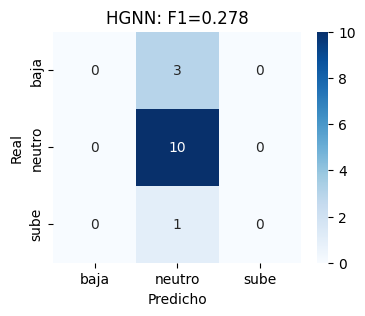

In [24]:
import numpy as np
import torch
from torch_geometric.loader import DataLoader
from src.modelo.arquitectura import HGNNGeopolitica
from src.entrenamiento.loop import entrenar_un_fold
from src.entrenamiento.evaluacion import calcular_metricas
import seaborn as sns
import matplotlib.pyplot as plt

# Entrenar la HGNN en el primer fold y guardar predicciones
f0 = folds[0]
m, hist, _ = entrenar_un_fold(dataset, f0.idx_train, f0.idx_val,
                            seed=0, dispositivo=dispositivo, verbose=False)

# Pintar la matriz de confusión de la HGNN
plt.figure(figsize=(4, 3))
sns.heatmap(m.matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['baja', 'neutro', 'sube'],
            yticklabels=['baja', 'neutro', 'sube'])
plt.title(f'HGNN: F1={m.f1_macro:.3f}')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

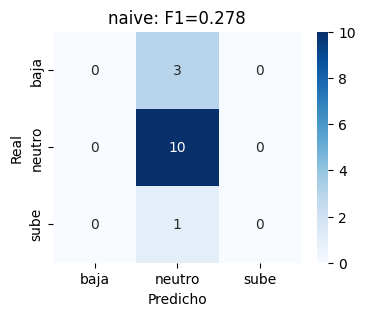

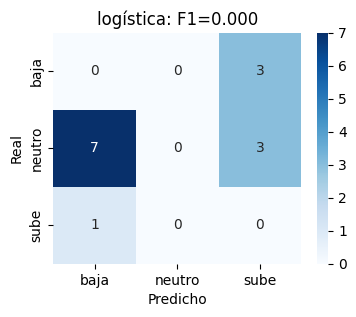

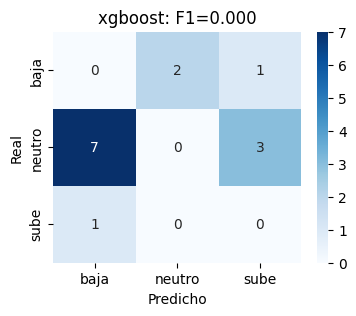

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from src.entrenamiento.evaluacion import calcular_metricas

# Para cada modelo
for nombre, modelo in [('naive', naive), ('logística', logr), ('xgboost', xgb)]:
    m = calcular_metricas(y_va, modelo.predict(X_va))
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        m.matriz_confusion,
        annot=True, fmt='d', cmap='Blues',
        xticklabels=['baja', 'neutro', 'sube'],
        yticklabels=['baja', 'neutro', 'sube'],
    )
    plt.title(f'{nombre}: F1={m.f1_macro:.3f}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

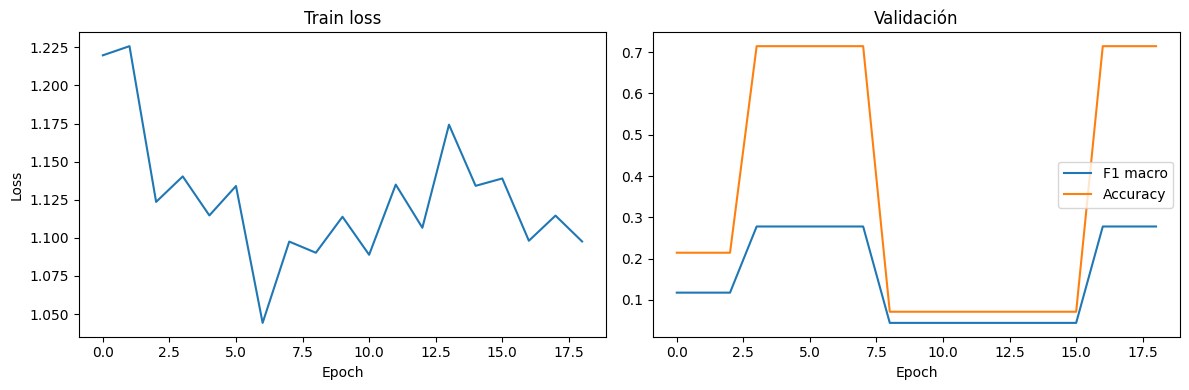

In [26]:
from src.entrenamiento.loop import entrenar_un_fold
import matplotlib.pyplot as plt

f0 = folds[0]
m, hist, _ = entrenar_un_fold(
    dataset, f0.idx_train, f0.idx_val,
    seed=0, dispositivo=dispositivo, verbose=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['train_loss'])
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(hist['val_f1'], label='F1 macro')
axes[1].plot(hist['val_acc'], label='Accuracy')
axes[1].set_title('Validación')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [27]:
data, clase = dataset[0]
print('Clase real:', clase)
print('Grafo:', data)
print()
print('Features del market:', data['market'].x)
print('Features de los países (primeras filas):')
print(data['country'].x[:5])
print()
print('Aristas país↔país:', data['country', 'interactua', 'country'].edge_index.shape[1])
print('Aristas país→market:', data['country', 'expone', 'market'].edge_index.shape[1])

Clase real: 1
Grafo: HeteroData(
  country={ x=[20, 11] },
  market={
    x=[1, 9],
    y=[1],
  },
  (country, interactua, country)={
    edge_index=[2, 807],
    edge_attr=[807, 7],
  },
  (country, expone, market)={
    edge_index=[2, 20],
    edge_attr=[20, 1],
  }
)

Features del market: tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, 21.9463,  9.7700,  0.0000,  1.4200,
          2.4600]])
Features de los países (primeras filas):
tensor([[-2.8295e+00, -5.5691e-01,  9.5672e+00,  1.3078e+01,  1.0000e+00,
          9.3764e+00,  9.7581e+00,  2.5488e-01,  2.5195e-01,  2.4162e-01,
          2.5155e-01],
        [-1.3827e+00,  3.7277e-01,  7.3484e+00,  1.0103e+01,  1.6000e-01,
          7.2089e+00,  7.4878e+00,  3.4252e-01,  2.6382e-01,  1.8524e-01,
          2.0842e-01],
        [-2.3923e+00, -4.6620e-02,  6.8972e+00,  9.9272e+00,  5.0000e-03,
          6.8298e+00,  6.9645e+00,  3.8532e-01,  2.4410e-01,  1.9550e-01,
          1.7507e-01],
        [-1.5519e+00,  6.2841e-01,  6.6498e+00,  9.

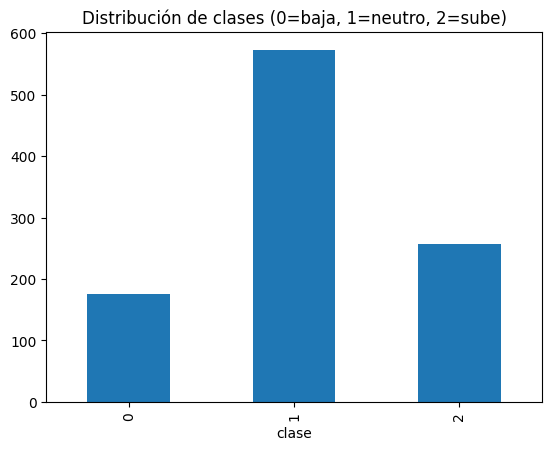

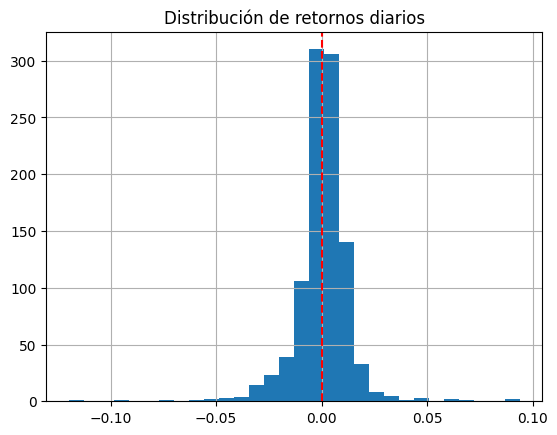

In [28]:
import matplotlib.pyplot as plt

# Distribución de clases en todo el dataset
etiquetas_validas['clase'].value_counts().sort_index().plot(
    kind='bar',
    title='Distribución de clases (0=baja, 1=neutro, 2=sube)',
)
plt.show()

# Distribución de retornos
etiquetas_validas['retorno'].hist(bins=30)
plt.title('Distribución de retornos diarios')
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [29]:
# Día con más eventos
fecha_max = df_agregado.groupby('fecha')['n_eventos'].sum().idxmax()
print(f'Día más activo: {fecha_max}')

df_agregado[df_agregado['fecha'] == fecha_max].sort_values('n_eventos', ascending=False).head(15)

Día más activo: 2018-05-09 00:00:00


,fecha,pais_origen,pais_destino,quadclass,n_eventos,goldstein_medio,tono_medio,num_mentions_total
87523,2018-05-09,USA,USA,1,1210,2.258678,-1.190216,38642
87526,2018-05-09,USA,USA,4,362,-7.618232,-4.988551,12505
87353,2018-05-09,PRK,USA,1,358,2.615922,-1.040254,45792
87524,2018-05-09,USA,USA,2,353,5.753541,-1.749799,16989
87504,2018-05-09,USA,PRK,1,346,2.721387,-0.624602,42135
87525,2018-05-09,USA,USA,3,291,-3.123024,-3.873433,9245
87484,2018-05-09,USA,IRN,1,286,3.141259,-2.174334,9369
87485,2018-05-09,USA,IRN,2,241,8.803320,-2.491308,12203
87249,2018-05-09,JPN,CHN,1,220,3.323636,0.565449,13114
87207,2018-05-09,IRN,USA,1,207,3.049758,-2.290426,8029


In [30]:
!pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.8 MB/s eta 0:00:00


In [31]:
import matplotlib.pyplot as plt
import numpy as np
from pyvis.network import Network
from google.colab import files
from src.utils.paises import ROSTER, INDICE_A_PAIS

def visualizar_grafo_limpio(data, fecha=None, top_aristas_cc=15, archivo='grafo.html'):
    """
    Grafo limpio:
    - Aristas país↔país agrupadas (suma de las QuadClass entre cada par)
    - Solo top N por peso
    - Color según predominio cooperación/conflicto
    - Aristas país→SP500 con grosor según comercio, normalizado
    """
    net = Network(height='800px', width='100%', directed=True,
                  notebook=False, cdn_resources='in_line', bgcolor='#ffffff')

    # ----- Agrupar aristas país↔país por par (origen, destino) -----
    ei_cc = data['country', 'interactua', 'country'].edge_index.cpu().numpy()
    ea_cc = data['country', 'interactua', 'country'].edge_attr.cpu().numpy()

    agrupado = {}
    for k in range(ei_cc.shape[1]):
        o, d = int(ei_cc[0, k]), int(ei_cc[1, k])
        peso = float(ea_cc[k, 0])
        quad = int(ea_cc[k, 3:7].argmax())
        es_conflicto = quad >= 2

        key = (o, d)
        if key not in agrupado:
            agrupado[key] = {'peso': 0.0, 'coop': 0.0, 'conf': 0.0}
        agrupado[key]['peso'] += peso
        if es_conflicto:
            agrupado[key]['conf'] += peso
        else:
            agrupado[key]['coop'] += peso

    pares_ordenados = sorted(agrupado.items(), key=lambda x: x[1]['peso'], reverse=True)
    top_pares = pares_ordenados[:top_aristas_cc]

    # ----- Países que aparecen en las top aristas o con comercio relevante -----
    paises_activos = set()
    for (o, d), _ in top_pares:
        paises_activos.add(o)
        paises_activos.add(d)

    ei_cm = data['country', 'expone', 'market'].edge_index.cpu().numpy()
    ea_cm = data['country', 'expone', 'market'].edge_attr.cpu().numpy()
    for j in range(ei_cm.shape[1]):
        if float(ea_cm[j, 0]) > 0.05:
            paises_activos.add(int(ei_cm[0, j]))

    # ----- Añadir nodos país -----
    for i in paises_activos:
        p = ROSTER[i]
        feats = data['country'].x[i].tolist()
        tono = float(feats[0])
        goldstein = float(feats[1])
        if goldstein < -1:
            color = '#ff8787'
        elif goldstein > 1:
            color = '#8ce99a'
        else:
            color = '#a5d8ff'
        titulo = (f"<b>{p.nombre}</b><br>"
                  f"Tono: {tono:.2f}<br>"
                  f"Goldstein: {goldstein:.2f}")
        net.add_node(p.id, label=p.id, title=titulo,
                     color=color, size=22, font={'size': 14, 'face': 'arial'})

    # ----- Nodo SP500 -----
    sp = data['market'].x[0].tolist()
    titulo_sp = (f"<b>S&P 500</b><br>"
                 f"Retorno 1d: {float(sp[0]):.4f}<br>"
                 f"Volatilidad 21d: {float(sp[3]):.4f}")
    net.add_node('SP500', label='SP500', title=titulo_sp,
                 color='#ffd43b', size=38, shape='diamond',
                 font={'size': 16, 'face': 'arial'})

    # ----- Aristas país↔país (top N agrupadas) -----
    pesos_top = np.array([v['peso'] for _, v in top_pares])
    peso_max = float(pesos_top.max()) if len(pesos_top) else 1.0

    for (o, d), v in top_pares:
        origen_id = INDICE_A_PAIS[o]
        destino_id = INDICE_A_PAIS[d]
        ancho = float(1.0 + 5.0 * (v['peso'] / peso_max))
        if v['conf'] > v['coop'] * 1.2:
            color = '#e03131'
        elif v['coop'] > v['conf'] * 1.2:
            color = '#2f9e44'
        else:
            color = '#868e96'
        titulo = (f"{origen_id} → {destino_id}<br>"
                  f"Peso total: {float(v['peso']):.2f}<br>"
                  f"Cooperación: {float(v['coop']):.2f}<br>"
                  f"Conflicto: {float(v['conf']):.2f}")
        net.add_edge(origen_id, destino_id,
                     width=ancho, color=color,
                     title=titulo)

    # ----- Aristas país → SP500 -----
    pesos_cm = ea_cm[:, 0]
    peso_cm_max = float(pesos_cm.max()) if len(pesos_cm) else 1.0

    for j in range(ei_cm.shape[1]):
        idx_pais = int(ei_cm[0, j])
        if idx_pais not in paises_activos:
            continue
        peso = float(ea_cm[j, 0])
        if peso <= 0.05:
            continue
        origen_id = INDICE_A_PAIS[idx_pais]
        ancho = float(0.5 + 3.5 * (peso / peso_cm_max))
        net.add_edge(origen_id, 'SP500',
                     width=ancho, color='#ffa94d',
                     dashes=True,
                     title=f"Comercio {origen_id}↔USA: {peso:.3f}")

    # Opciones de layout
    net.set_options("""
    {
      "physics": {
        "forceAtlas2Based": {
          "gravitationalConstant": -80,
          "centralGravity": 0.01,
          "springLength": 150,
          "springConstant": 0.08
        },
        "solver": "forceAtlas2Based",
        "stabilization": {"iterations": 200}
      },
      "edges": {
        "arrows": {"to": {"enabled": true, "scaleFactor": 0.5}},
        "smooth": {"type": "curvedCW", "roundness": 0.15}
      },
      "interaction": {"hover": true}
    }
    """)

    html = net.generate_html(notebook=False)
    with open(archivo, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"HTML generado: {archivo}")
    files.download(archivo)


data, clase = dataset[0]
fecha = etiquetas_validas.iloc[0]['fecha_grafo']
visualizar_grafo_limpio(data, fecha=fecha, top_aristas_cc=15)

HTML generado: grafo.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

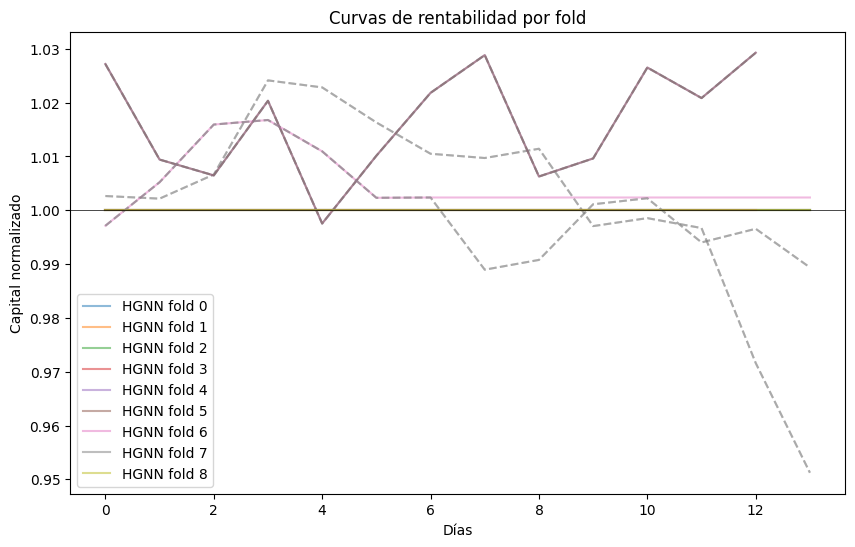

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i, mf in enumerate(resultado.metricas_financieras_por_fold):
    plt.plot(mf.curva_estrategia, alpha=0.5, label=f'HGNN fold {i}')
    plt.plot(mf.curva_buy_hold, alpha=0.3, color='gray', linestyle='--')
plt.axhline(1.0, color='black', linewidth=0.5)
plt.ylabel('Capital normalizado')
plt.xlabel('Días')
plt.legend()
plt.title('Curvas de rentabilidad por fold')
plt.show()